In [1]:
import pandas as pd
import numpy as np
import plotly as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer
import seaborn as sns                       
import matplotlib.pyplot as plt             
%matplotlib inline     
sns.set(color_codes=True)

In [2]:
df = pd.read_csv('../data/social_media_vs_productivity.csv')

In [3]:
df.shape

(30000, 19)

In [4]:
df.columns.tolist()

['age',
 'gender',
 'job_type',
 'daily_social_media_time',
 'social_platform_preference',
 'number_of_notifications',
 'work_hours_per_day',
 'perceived_productivity_score',
 'actual_productivity_score',
 'stress_level',
 'sleep_hours',
 'screen_time_before_sleep',
 'breaks_during_work',
 'uses_focus_apps',
 'has_digital_wellbeing_enabled',
 'coffee_consumption_per_day',
 'days_feeling_burnout_per_month',
 'weekly_offline_hours',
 'job_satisfaction_score']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [6]:
df.nunique()

age                                  48
gender                                3
job_type                              6
daily_social_media_time           25375
social_platform_preference            5
number_of_notifications              61
work_hours_per_day                29821
perceived_productivity_score      28386
actual_productivity_score         27635
stress_level                         10
sleep_hours                       26926
screen_time_before_sleep          25567
breaks_during_work                   11
uses_focus_apps                       2
has_digital_wellbeing_enabled         2
coffee_consumption_per_day           11
days_feeling_burnout_per_month       32
weekly_offline_hours              26737
job_satisfaction_score            27079
dtype: int64

In [7]:
df.isnull().sum()

age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

In [8]:
# процент пропущенных данных по столбцам
(df.isnull().sum()/(len(df)))*100

age                               0.000000
gender                            0.000000
job_type                          0.000000
daily_social_media_time           9.216667
social_platform_preference        0.000000
number_of_notifications           0.000000
work_hours_per_day                0.000000
perceived_productivity_score      5.380000
actual_productivity_score         7.883333
stress_level                      6.346667
sleep_hours                       8.660000
screen_time_before_sleep          7.370000
breaks_during_work                0.000000
uses_focus_apps                   0.000000
has_digital_wellbeing_enabled     0.000000
coffee_consumption_per_day        0.000000
days_feeling_burnout_per_month    0.000000
weekly_offline_hours              0.000000
job_satisfaction_score            9.100000
dtype: float64

In [9]:
# проверка на наличие ненужных символов
for col in df.columns:
    print('{} : {}'.format(col,df[col].unique()))

age : [56 46 32 60 25 38 36 40 28 41 53 57 20 39 19 61 47 55 50 29 42 44 59 45
 33 64 54 24 26 35 21 31 43 37 52 34 23 51 27 48 65 62 58 18 22 30 49 63]
gender : ['Male' 'Female' 'Other']
job_type : ['Unemployed' 'Health' 'Finance' 'IT' 'Education' 'Student']
daily_social_media_time : [ 4.18093978  3.24960295         nan ...  4.43778435 17.72498127
  3.79663389]
social_platform_preference : ['Facebook' 'Twitter' 'Telegram' 'TikTok' 'Instagram']
number_of_notifications : [61 59 57 66 50 60 49 64 77 65 67 52 47 62 63 58 73 56 55 74 46 51 48 45
 72 69 53 76 70 71 54 42 37 68 79 75 36 39 83 40 44 86 43 89 80 84 81 41
 82 78 31 87 90 85 38 34 35 32 30 33 88]
work_hours_per_day : [ 6.75355841  9.16929612  7.91095203 ... 10.91503554  6.93740956
  8.06988298]
perceived_productivity_score : [8.04046395 5.06336816 3.86176246 ... 8.61100467 7.76707611 6.31122723]
actual_productivity_score : [7.29155527 5.165093   3.47405317 ... 8.65891154 6.89558333 5.40272551]
stress_level : [ 4.  7.  6.  5.  3.

#### Визуализируем пропуски данных

<Axes: >

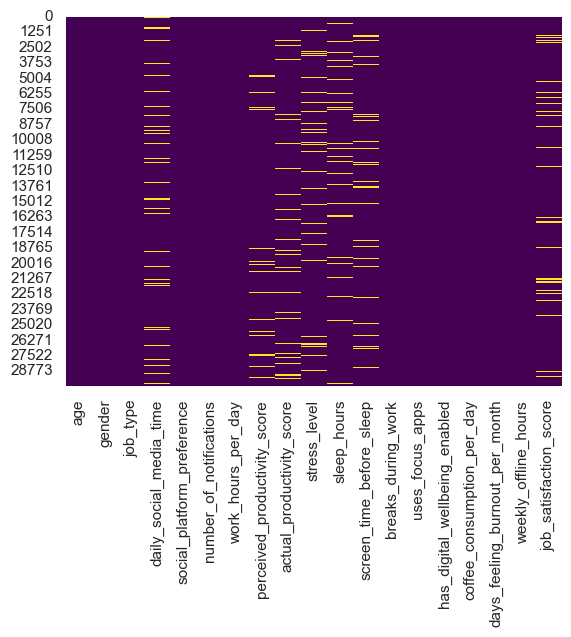

In [10]:
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

#### По графику и таблицам ясно, что пропущенных данные нужно импьютировать. Заполняем пропуски в столбцах `daily_social_media_time`, `perceived_productivity_score`, `actual_productivity_score`, `stress_level`, `sleep_hours`, `screen_time_before_sleep`, `job_satisfaction_score`

In [11]:
# разделим колонки на категориальные и нумерические
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns

In [12]:
imputer_mean = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer_mean.fit_transform(df[numeric_cols])

In [13]:
imputer_mode = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_mode.fit_transform(df[categorical_cols])

In [14]:
# данные после импьютации
df.isnull().sum()

age                               0
gender                            0
job_type                          0
daily_social_media_time           0
social_platform_preference        0
number_of_notifications           0
work_hours_per_day                0
perceived_productivity_score      0
actual_productivity_score         0
stress_level                      0
sleep_hours                       0
screen_time_before_sleep          0
breaks_during_work                0
uses_focus_apps                   0
has_digital_wellbeing_enabled     0
coffee_consumption_per_day        0
days_feeling_burnout_per_month    0
weekly_offline_hours              0
job_satisfaction_score            0
dtype: int64

In [15]:
df.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,41.486867,3.113418,59.958767,6.990792,5.510488,4.951805,5.514059,6.500247,1.025568,4.992200,1.999300,15.557067,10.360655,4.964901
std,13.835221,1.976884,7.723772,1.997736,1.968285,1.807615,2.773891,1.399175,0.628817,3.173737,1.410047,9.252956,7.280415,2.022374
min,18.000000,0.000000,30.000000,0.000000,2.000252,0.296812,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.797748,55.000000,5.643771,3.858604,3.509336,3.000000,5.598942,0.569569,2.000000,1.000000,8.000000,4.541872,3.528486
50%,41.000000,3.113418,60.000000,6.990641,5.510488,4.951805,5.514059,6.500247,1.025568,5.000000,2.000000,16.000000,10.013677,4.964901
75%,53.000000,4.219533,65.000000,8.354725,7.168062,6.396285,8.000000,7.398974,1.435798,8.000000,3.000000,24.000000,15.300809,6.407090
max,65.000000,17.973256,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,10.000000,31.000000,40.964769,10.000000


In [16]:
columns = df.describe().columns.to_list()
rows = 4
cols = 4

fig = make_subplots(rows=rows, cols=cols, vertical_spacing=0.03, subplot_titles=columns)

for i, col in enumerate(columns):
    row = i // cols + 1
    col_num = i % cols + 1
    fig.add_trace(go.Box(y=df[col], name=col, boxpoints='outliers'), row=row, col=col_num)

fig.update_layout(
    height=500 * rows,
    width=1200,
    title_text="Boxplots по числовым колонкам",
    showlegend=False
)

fig.show()

In [17]:
df.describe(include='object')

,gender,job_type,social_platform_preference,uses_focus_apps,has_digital_wellbeing_enabled
count,30000,30000,30000,30000,30000
unique,3,6,5,2,2
top,Male,Education,TikTok,False,False
freq,14452,5055,6096,20979,22602


In [18]:
columns = df.describe(include='object').columns.to_list()
rows = 2
cols = 3

fig = make_subplots(rows=rows, cols=cols, vertical_spacing=0.1, subplot_titles=columns)


for i, col in enumerate(columns):
    row = i // cols + 1
    col_num = i % cols + 1
    fig.add_trace(go.Histogram(x=df[col], name=col), row=row, col=col_num)


fig.update_layout(
    height=500 * rows, 
    width=800,
    title_text="Barplots по числовым колонкам",
    showlegend=False
)

fig.show()

#### Распределение числовых переменных

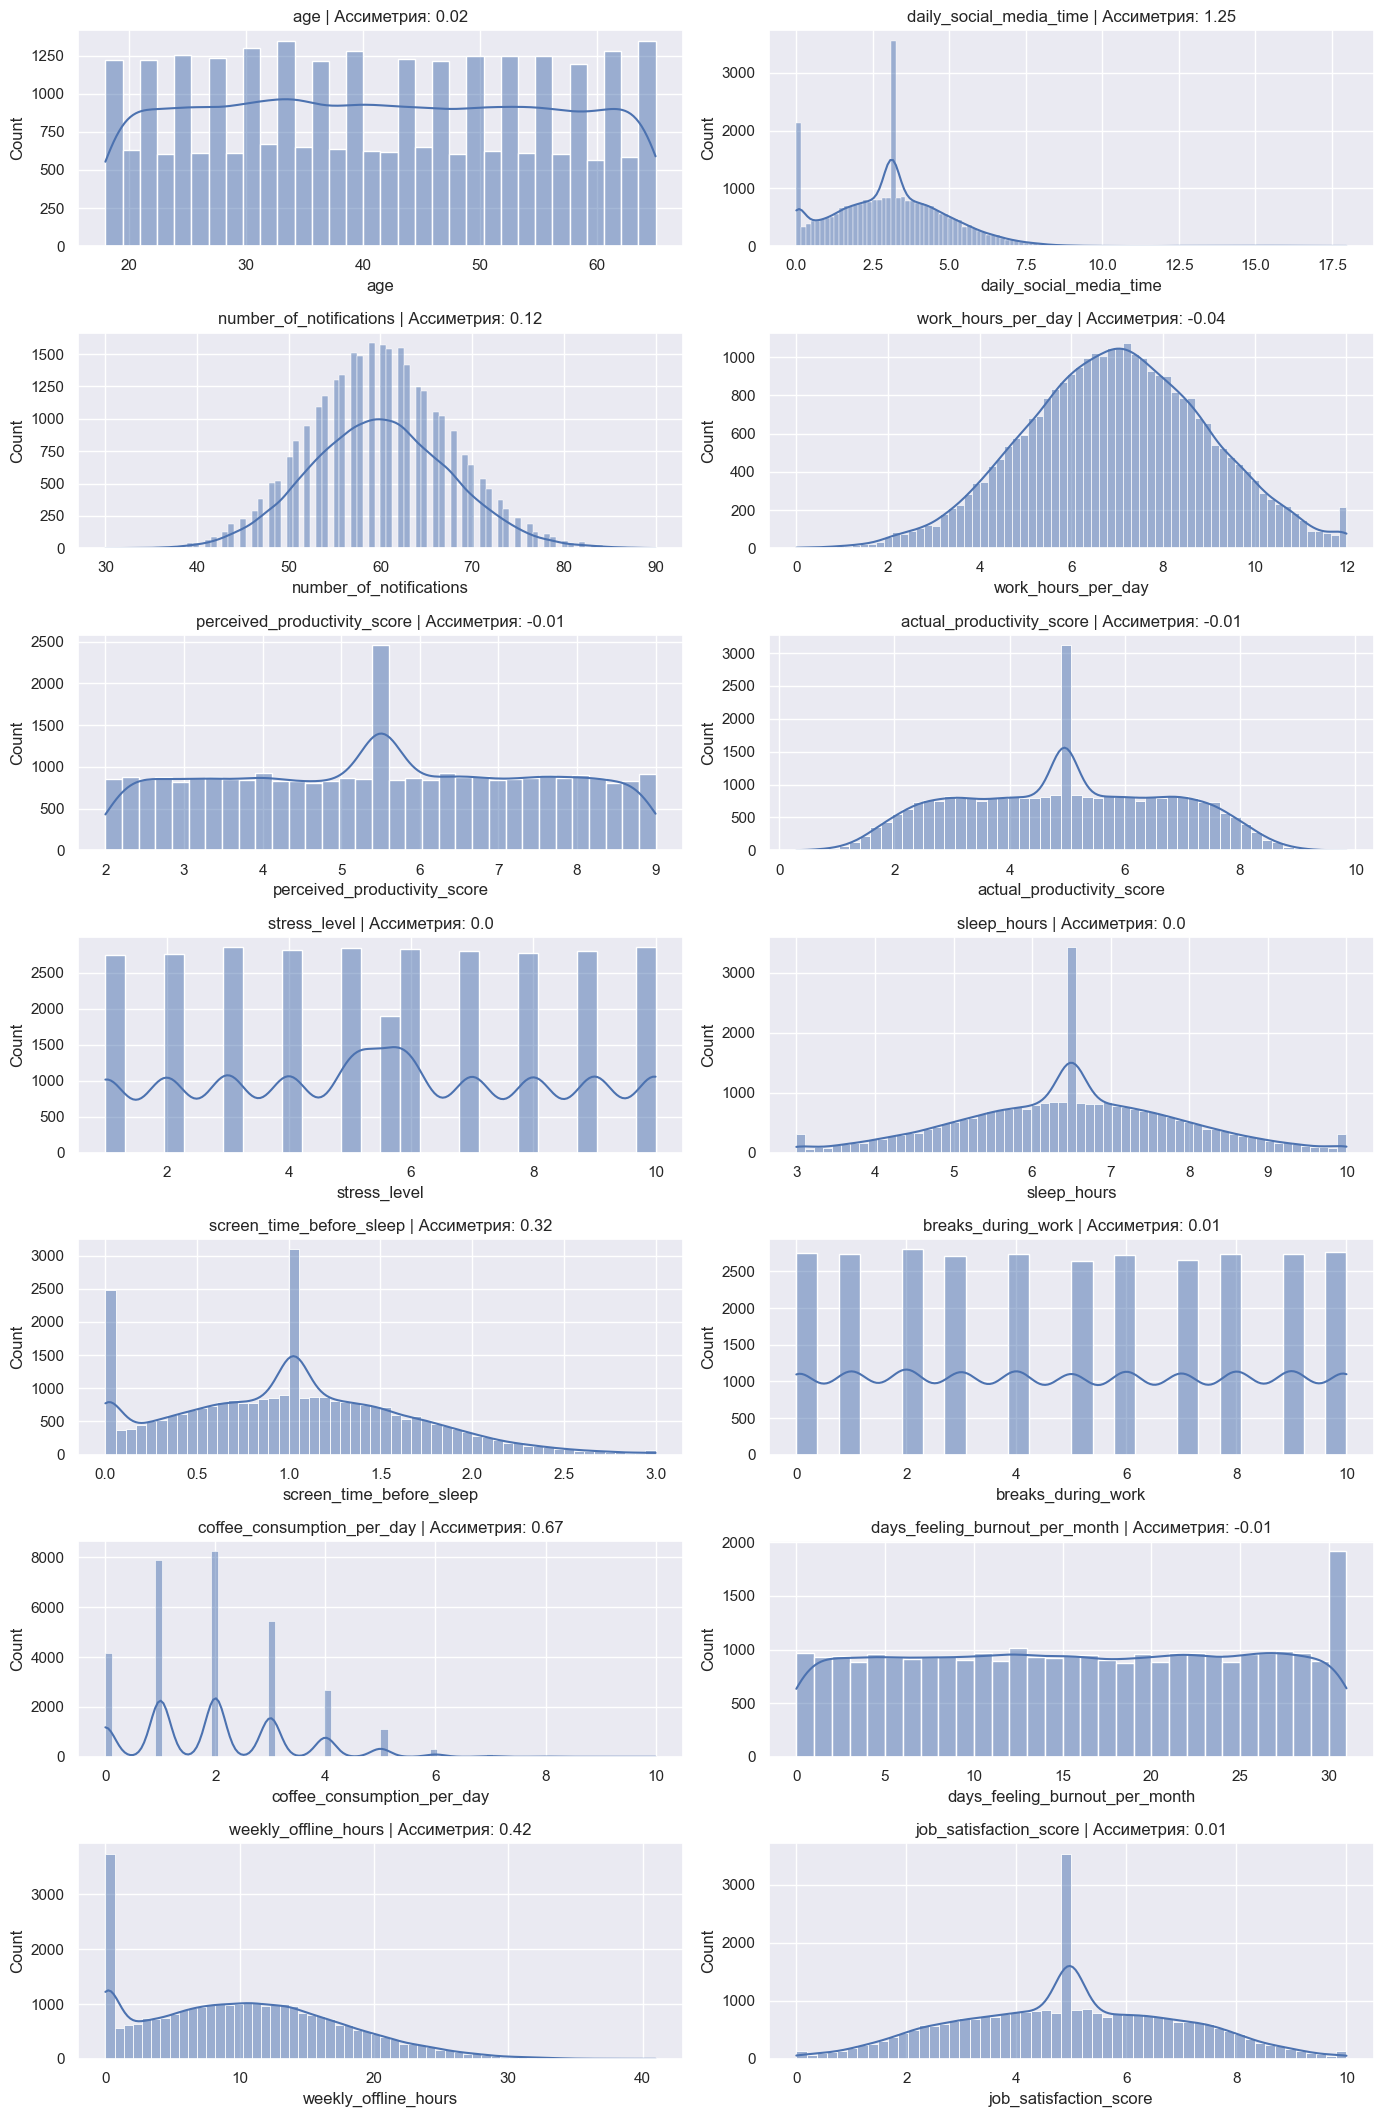

In [19]:
sns.set_style("darkgrid")

plt.figure(figsize=(14, len(numeric_cols) * 3))
for idx, feature in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Ассиметрия: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

#### Можно заметить, что многие переменные распределены нормально, по данным столбцов `daily_social_media_time `, `weekly_offline_hours `, `screen_time_before_sleep ` можно сразу увидеть наличие цифровых зависимостей в наблюдаемых данных

In [20]:
# проверим корреляцию между числовыми данными 
matrix = df.select_dtypes(include=["float64", "int64"]).corr()
fig = px.imshow(matrix, text_auto=True, 
    title='Корреляционная матрица',
    aspect='auto'
)

fig.update_layout(
    xaxis_title="Признаки",
    yaxis_title="Признаки",
    width=900,
    height=800
)
fig.show()

##### Можно заметить, что корреляция в основном у нас проявляется между данными в столбцах `perceived_productivity_score`, `	actual_productivity_score` и `job_satisfaction_score`

#### Сегментный анализ

In [25]:
#разбиваем людей на группы по возрасту
seg_df = df.copy()
seg_df['age_group'] = pd.cut(df['age'], bins=[17, 24, 34, 44, 54, 100], labels=['18-24', '25-34', '35-44', '45-54', '55+'])

In [26]:
seg_df['stress_group'] = pd.cut(df['stress_level'], bins=[0, 3, 6, 10], labels=['Low', 'Medium', 'High'])

# Создаем категорию уведомлений
seg_df['notification_group'] = pd.cut(df['number_of_notifications'], bins=[0, 40, 60, 90], labels=['Low', 'Medium', 'High'])

In [49]:
age_seg_df = seg_df.groupby('age_group')[['daily_social_media_time', 'screen_time_before_sleep', 'stress_level', 'actual_productivity_score']].mean()

C:\Users\Алина\AppData\Local\Temp\ipykernel_27748\1035985028.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
fig = go.Figure()

for col in age_seg_df.columns:
    fig.add_trace(go.Bar(
        x=age_seg_df.index,
        y=age_seg_df[col],
        name=col
    ))

fig.update_layout(
    title='Average Metrics by Age Group',
    xaxis_title='Age Group',
    yaxis_title='Mean Value',
    barmode='group'  
)

fig.show()

In [54]:
age_seg_df

,daily_social_media_time,screen_time_before_sleep,stress_level,actual_productivity_score
age_group,,,,
18-24,3.134251,1.026070,5.455168,4.907698
25-34,3.090320,1.023252,5.513660,4.936170
35-44,3.158504,1.027006,5.555602,4.985754
45-54,3.111147,1.016883,5.472752,4.925858
55+,3.082738,1.033999,5.550983,4.986695


#### Поскольку графики визуально идентичны, а различия наблюдаются лишь в числовых значениях, можно заключить, что влияние возраста на рассматриваемые данные не прослеживается.

#### Проанализируем категории по профессиям: Какие профессии чаще используют focus apps? Кто наиболее стрессоустойчив?

In [66]:
job_seg_df= seg_df.groupby(['job_type'])[['social_platform_preference','uses_focus_apps', 'has_digital_wellbeing_enabled']].count()